In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
df = pd.read_csv("Customer_Churn_Dataset_200.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 200
Columns: 10


,CustomerID,Gender,Age,Tenure_Months,Monthly_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Churn
0,CUST001,Male,49,6,25.76,One year,Fiber optic,Electronic Check,7,Yes
1,CUST002,Female,56,37,74.95,Month-to-month,No,Credit Card,0,No
2,CUST003,Male,49,24,64.15,Month-to-month,DSL,Bank Transfer,4,Yes
3,CUST004,Male,21,46,108.77,One year,DSL,Electronic Check,2,Yes
4,CUST005,Male,47,53,55.09,Month-to-month,Fiber optic,Bank Transfer,2,No


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        200 non-null    str    
 1   Gender            200 non-null    str    
 2   Age               200 non-null    int64  
 3   Tenure_Months     200 non-null    int64  
 4   Monthly_Charges   200 non-null    float64
 5   Contract_Type     200 non-null    str    
 6   Internet_Service  200 non-null    str    
 7   Payment_Method    200 non-null    str    
 8   Support_Calls     200 non-null    int64  
 9   Churn             200 non-null    str    
dtypes: float64(1), int64(3), str(6)
memory usage: 15.8 KB


In [15]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CustomerID          0
Gender              0
Age                 0
Tenure_Months       0
Monthly_Charges     0
Contract_Type       0
Internet_Service    0
Payment_Method      0
Support_Calls       0
Churn               0
dtype: int64


In [16]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [17]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Support_Calls
count,200.000000,200.000000,200.000000,200.000
mean,42.060000,36.780000,70.320450,3.580
std,13.775165,20.436975,30.769624,2.229
min,18.000000,1.000000,21.140000,0.000
25%,30.750000,19.000000,40.855000,2.000
50%,44.000000,35.500000,69.800000,4.000
75%,53.000000,55.500000,97.875000,5.250
max,65.000000,71.000000,119.970000,7.000


In [18]:
print(df["Churn"].value_counts())

Churn
Yes    103
No      97
Name: count, dtype: int64


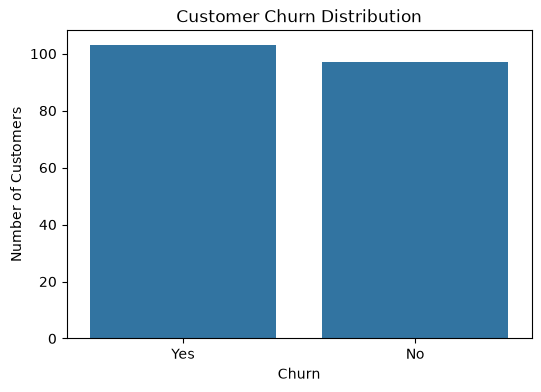

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

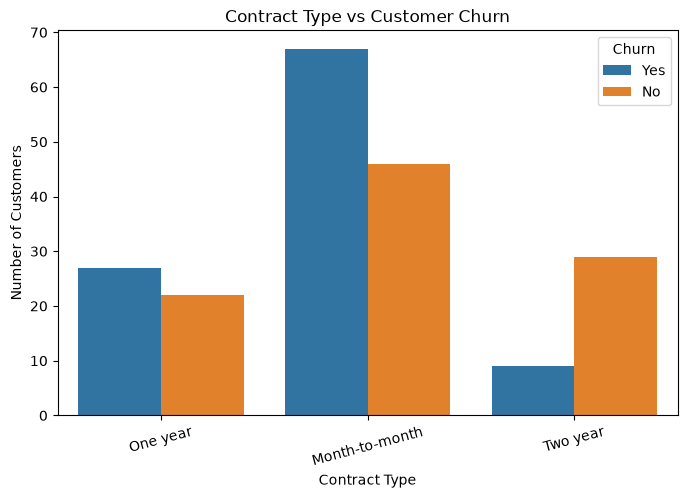

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract_Type", hue="Churn", data=df)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.show()

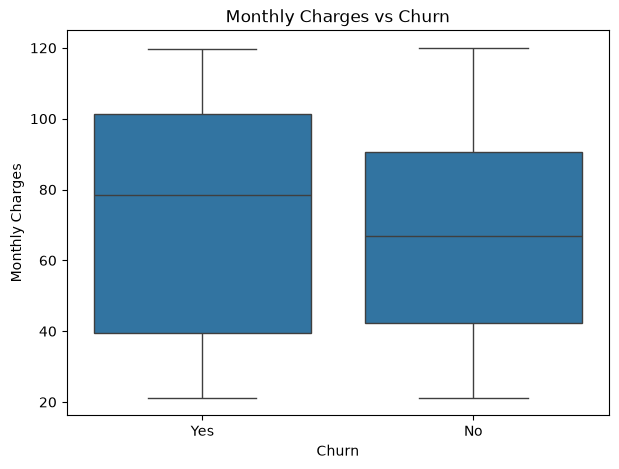

In [21]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Churn", y="Monthly_Charges", data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

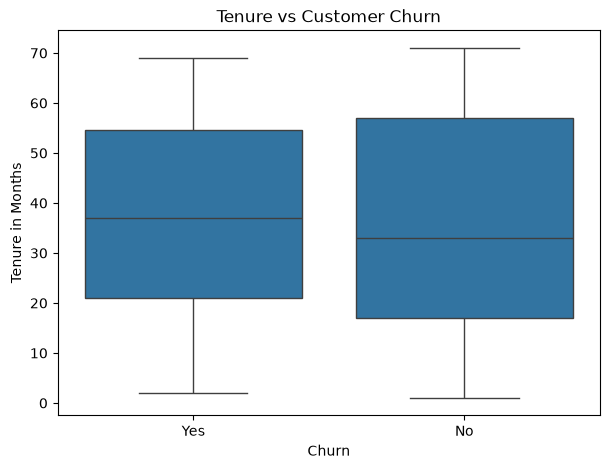

In [22]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Churn", y="Tenure_Months", data=df)

plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure in Months")

plt.show()

In [23]:
model_df = df.copy()

# Remove Customer ID
model_df = model_df.drop("CustomerID", axis=1)

# Convert categorical columns into numbers
encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Contract_Type",
    "Internet_Service",
    "Payment_Method",
    "Churn"
]

for column in categorical_columns:
    model_df[column] = encoder.fit_transform(model_df[column])

model_df.head()

,Gender,Age,Tenure_Months,Monthly_Charges,Contract_Type,Internet_Service,Payment_Method,Support_Calls,Churn
0,1,49,6,25.76,1,1,2,7,1
1,0,56,37,74.95,0,2,1,0,0
2,1,49,24,64.15,0,0,0,4,1
3,1,21,46,108.77,1,0,2,2,1
4,1,47,53,55.09,0,1,0,2,0


In [24]:
X = model_df.drop("Churn", axis=1)
y = model_df["Churn"]

print("Features:")
print(X.columns)

print("\nTarget: Churn")

Features:
Index(['Gender', 'Age', 'Tenure_Months', 'Monthly_Charges', 'Contract_Type',
       'Internet_Service', 'Payment_Method', 'Support_Calls'],
      dtype='str')

Target: Churn


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 160
Testing Records: 40


In [26]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [27]:
y_pred = model.predict(X_test)

print("Prediction completed!")
print(y_pred)

Prediction completed!
[0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1 1 1 0 0 1 1
 0 1 0]


In [28]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 60.0 %


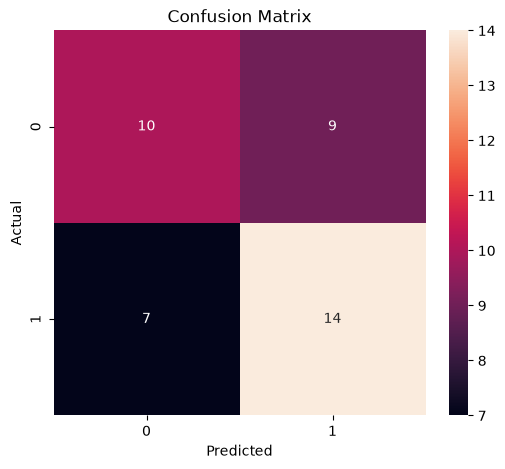

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.53      0.56        19
           1       0.61      0.67      0.64        21

    accuracy                           0.60        40
   macro avg       0.60      0.60      0.60        40
weighted avg       0.60      0.60      0.60        40



In [31]:
sample_customer = X_test.iloc[[0]]

prediction = model.predict(sample_customer)[0]

if prediction == 1:
    print("Prediction: Customer is likely to CHURN")
else:
    print("Prediction: Customer is likely to STAY")

Prediction: Customer is likely to STAY
